# Load Intraday Auction Data (IDA)

In [1]:
import pandas as pd

In [2]:
dfs = []
for i in range(1, 53):
    df = pd.read_csv(f'energy-charts_Stromproduktion_und_Börsenstrompreise_in_Deutschland_in_Woche_{i}_2025.csv', 
                     sep=';', 
                     decimal=',',
                     header=None,
                     index_col=0
                    )
    df.sort_index(inplace=True) 
    dfs.append(df)

In [3]:
ida = pd.concat(dfs)

In [4]:
ida.head()

,1
0,
1.0,86.585943
2.0,83.518208
3.0,75.519725
4.0,68.232719
5.0,86.079054


In [5]:
# Set index manually (local time)
# Must be exaxctly 52 weeks = 34944 quarter-hours
ida.rename(columns={1: 'IDA'}, inplace=True)
ida.index = pd.date_range(start='2024-12-30 00:00', 
                         end='2025-12-28 23:45', 
                         freq='15min ')

In [6]:
ida.describe()

,IDA
count,34944.000000
mean,89.595910
std,53.994331
min,-259.555008
25%,69.147649
50%,91.787796
75%,114.897162
max,853.263707


<Axes: >

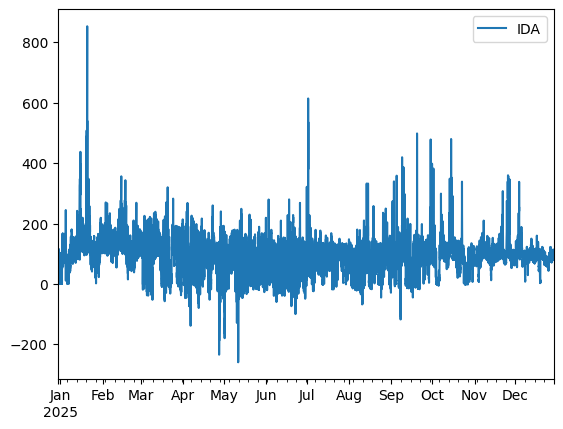

In [7]:
ida.plot()

In [8]:
ida.to_csv('2025_ida.csv')